### Variable Interest Rate and Zero Coupon Bond

Assume we have a zero-coupon bond selling at $0.92 with face value $1 after 360 days

We know that the interest rate is going to increase by 200 basis points at day 180

When to sell the bond if the goal is a log-return of 4.88% ?

In [8]:
import numpy as np
import matplotlib.pyplot as plt

F = 1
price_day_0 = 0.92

rate_0_360 = np.log(F / price_day_0)
rate_180_360 = rate_0_360 + 0.02

print(f"The interest rate before day 180 is {round(rate_0_360 * 100, 2)}%")
print(f"The interest rate after day 180 is {round(rate_180_360 * 100, 2)}%")

The interest rate before day 180 is 8.34%
The interest rate after day 180 is 10.34%


In [11]:
# Target bond value to achieve k = 0.0488 when sold
price_target = price_day_0 * np.exp(0.0488)

# Can we achieve this price target in the first 180 days? 
price_day_179 = price_day_0 * np.exp(179/360 * rate_0_360)

print(f"The target price to achieve 4.88% log-return is {round(price_target, 4)}")
print(f"Notice that at day 179 the bond price is {round(price_day_179, 4)} < target price")

The target price to achieve 4.88% log-return is 0.966
Notice that at day 179 the bond price is 0.9589 < target price


In [13]:
# When interest rate goes up, bond value goes down
price_day_180 = F * np.exp(-(360-180)/360 * rate_180_360)
print(f"Because interest rate increases, the value of the bond decreases to {round(price_day_180, 4)}")

# We achieve the price target after x days from day 180
x = 360/rate_180_360 * np.log(price_target / price_day_180)
print(f'Price target of {round(price_target, 4)} is achieved when bond is sold after day {round(x + 180)}')

Because interest rate increases, the value of the bond decreases to 0.9496
Price target of 0.966 is achieved when bond is sold after day 240


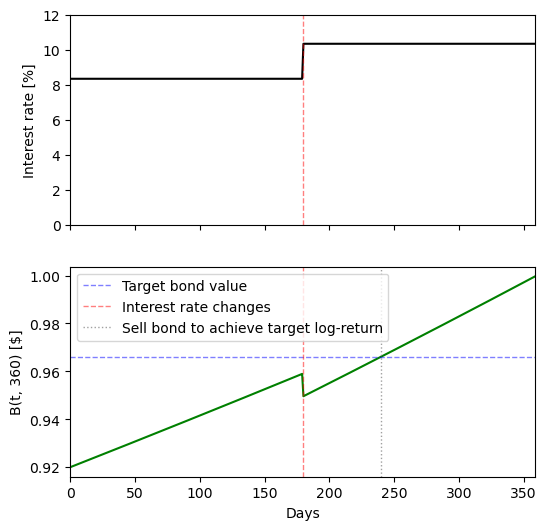

In [41]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

days = np.arange(0, 360)
rates = np.where(days < 180, round(rate_0_360 * 100, 2), round(rate_180_360 * 100, 2))
ax[0].plot(days, rates, color='black')
ax[0].axvline(180, lw=1, ls='--', color='red', alpha=0.5)
ax[0].set_xlim(days[0], days[-1])
ax[0].set_ylim(0, 12)
ax[0].set_ylabel('Interest rate [%]')

bond_price = np.where(
    days < 180,
    price_day_0 * np.exp(rate_0_360 * days / 360),
    price_day_180 * np.exp(rate_180_360 * (days - 180) / 360)
)
ax[1].plot(days, bond_price, color='green')
ax[1].axhline(price_target, lw=1, ls='--', color='blue', alpha=0.5, label='Target bond value')
ax[1].axvline(180, lw=1, ls='--', color='red', alpha=0.5, label='Interest rate changes')
ax[1].axvline(240, lw=1, ls=':', color='grey', alpha=0.75, label='Sell bond to achieve target log-return')
ax[1].set_xlabel('Days')
ax[1].set_ylabel('B(t, 360) [$]')
ax[1].legend()
plt.show()
